## Read dynamic prompt results

In [1]:
import pickle
import os
import glob

# Get all files in the directory
files = glob.glob('extension_plots/best_values_tracking_v*.pickle')
# Sort files by modification time
files.sort(key=os.path.getmtime, reverse=True)
# Load the most recent file
if files:
    latest_file = files[0]
    with open(latest_file, 'rb') as f:
        best_values = pickle.load(f)
    print(f"Loaded best_values from {latest_file}")
else:
    print("No best_values files found in the directory.")

print(f"Loaded {len(best_values)} best_values entries.")

Loaded best_values from extension_plots/best_values_tracking_v20250617_101115.pickle
Loaded 4 best_values entries.


🎨 Creating final extension plots for journal submission...


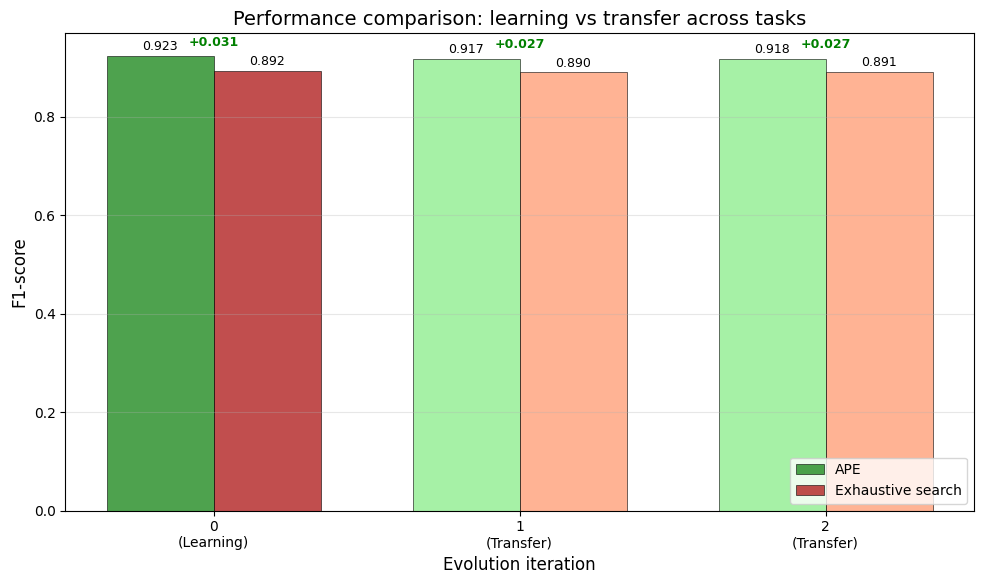

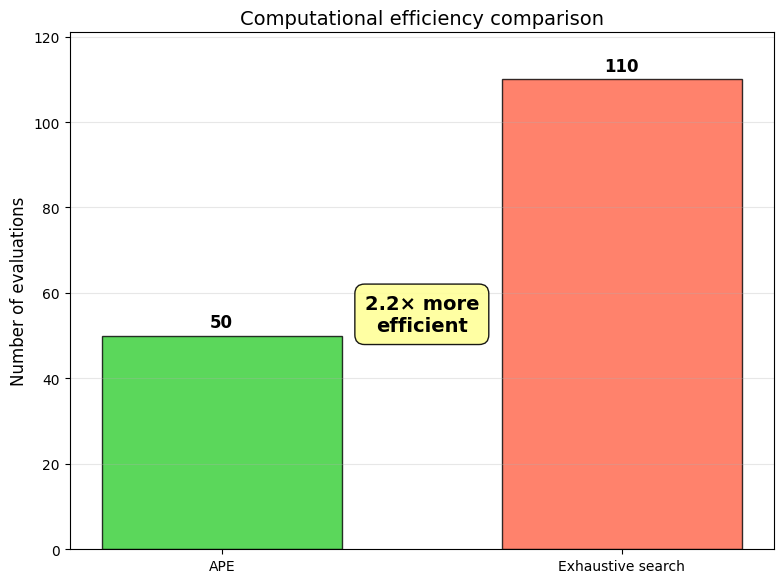

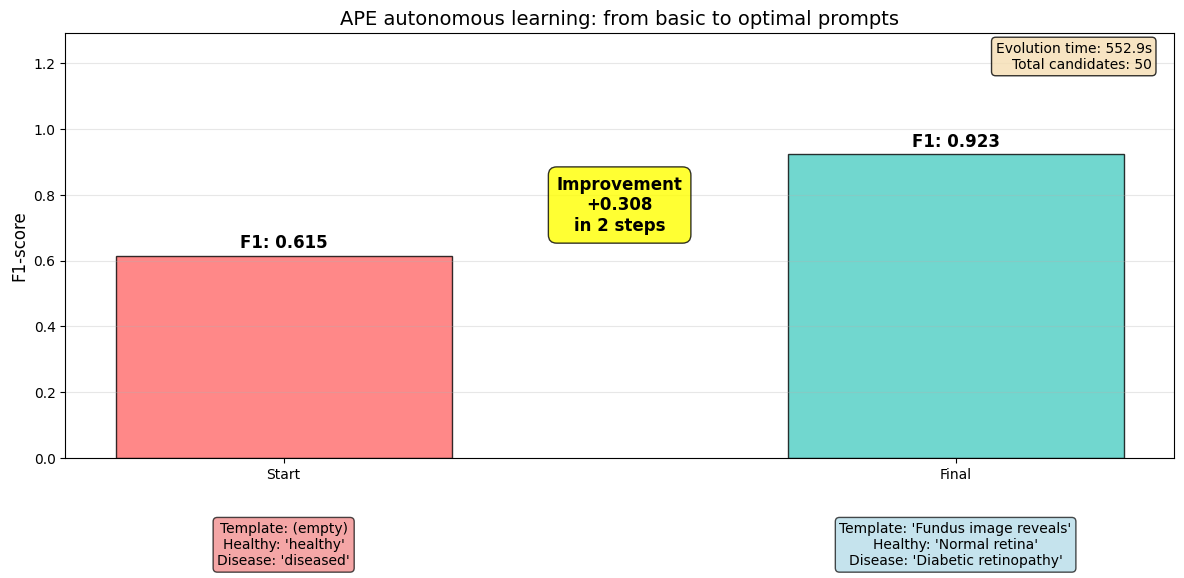

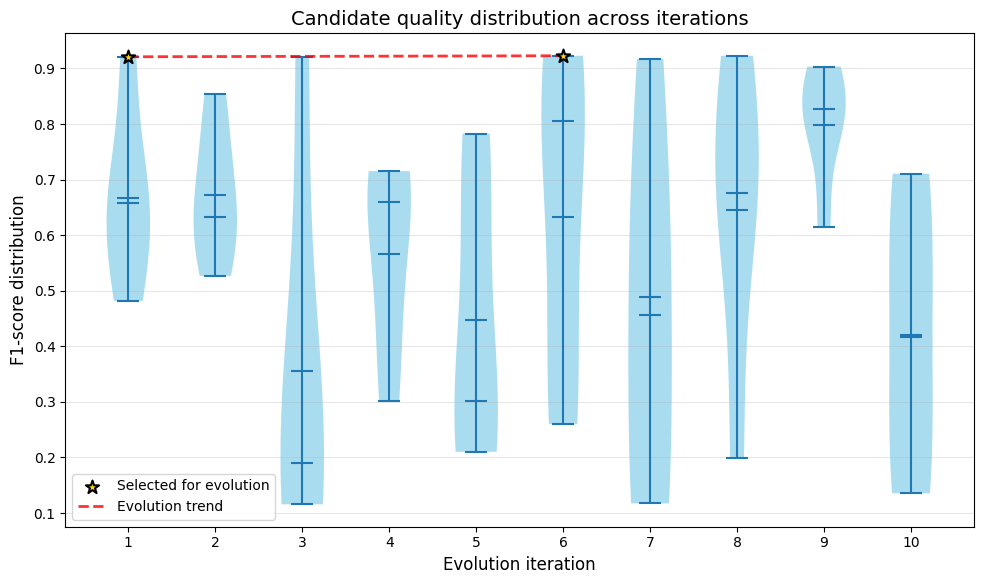

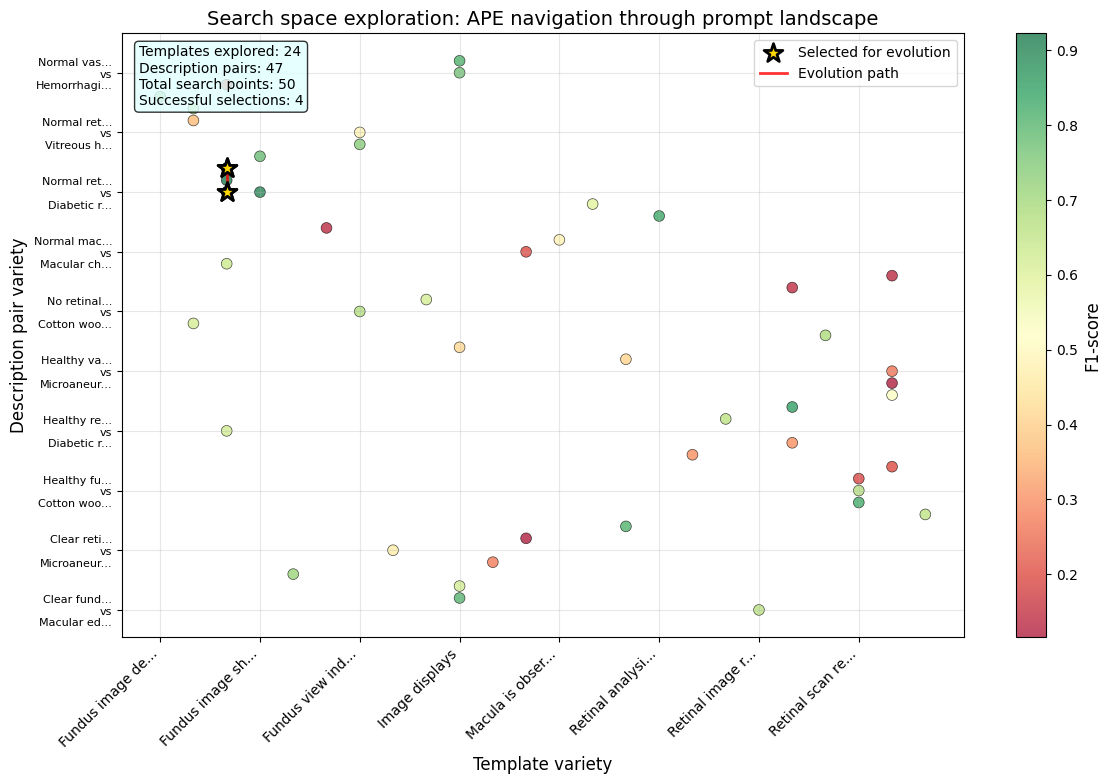

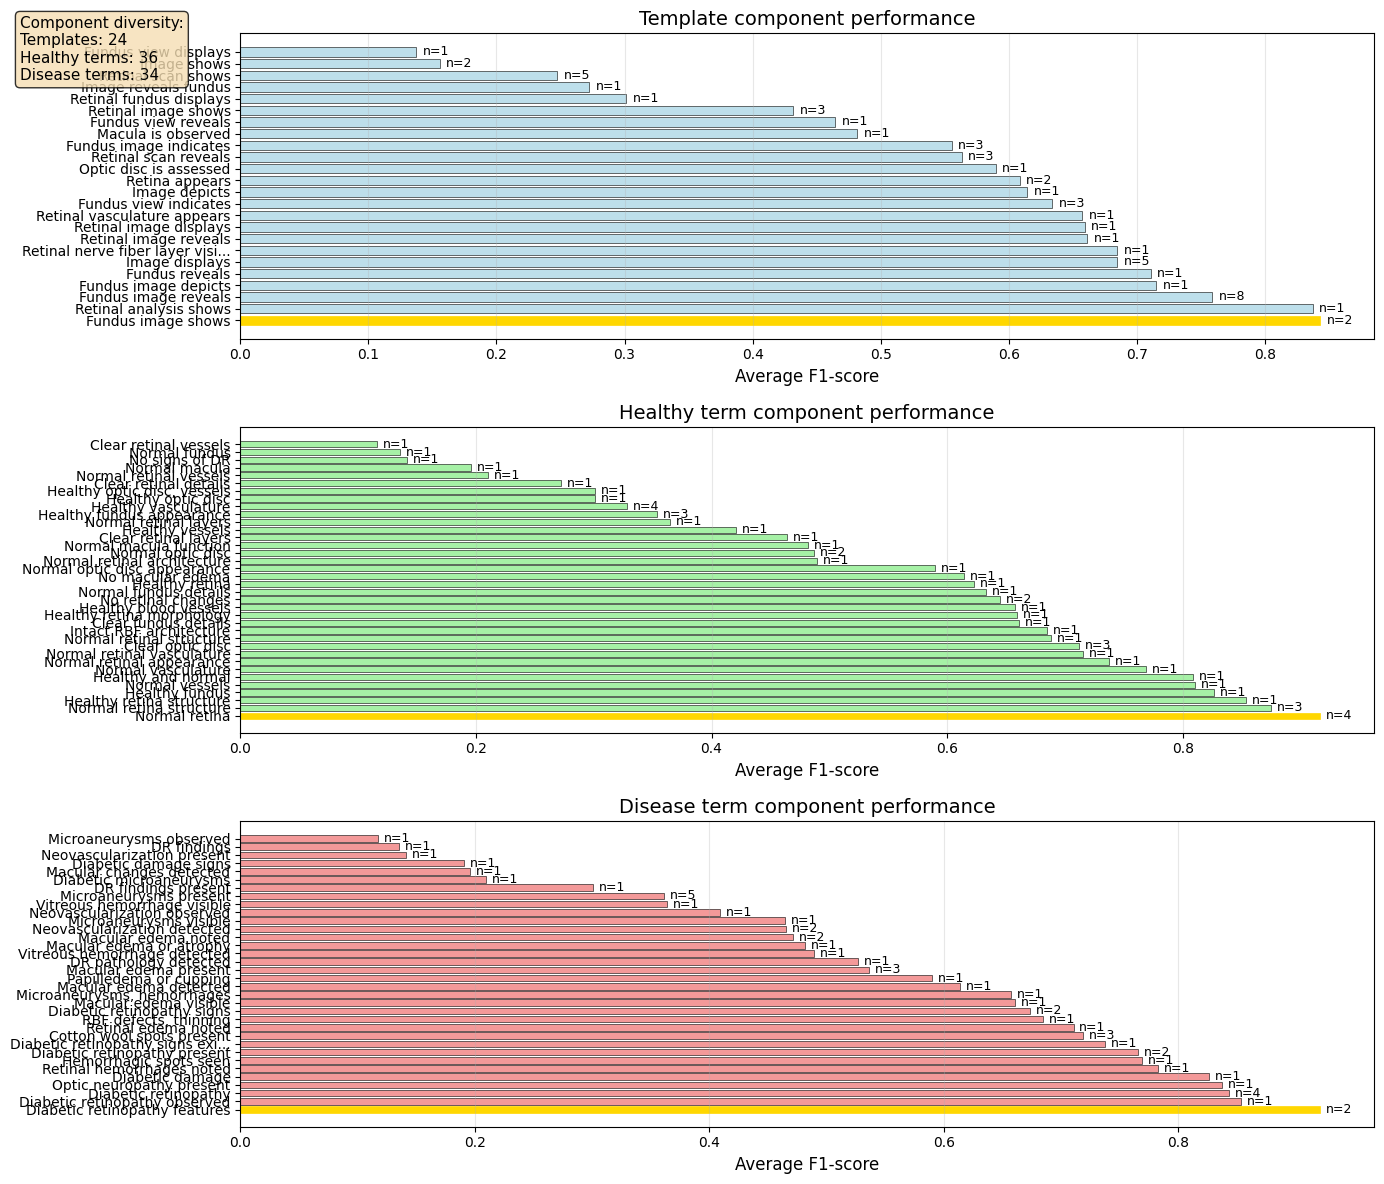

✅ All final extension plots created!
📁 Plots saved in: ./extension_plots/

Plot summary:
  1. performance_analysis.pdf - Learning vs transfer across tasks
  2. computational_efficiency.pdf - Efficiency comparison
  3. learning_progression.pdf - Start vs final stages evolution
  4. candidate_quality_distribution.pdf - Solution space exploration
  5. search_space_exploration.pdf - Novel prompt landscape navigation
  6. prompt_component_analysis.pdf - Breakdown of prompt components


In [3]:
import os
os.makedirs('extension_plots', exist_ok=True)

from ape.plots import create_final_extension_plots

create_final_extension_plots(best_values)


## Results of CL experiments

In [5]:
import pandas as pd

df_tadiler = pd.read_csv('df_results_all.csv')
df_ape = pd.read_csv('./extension_plots/df_results_all.csv')


original_tadiler = df_tadiler[df_tadiler['Method'].str.contains('Original')].copy()


# Get TADILER (rename 'Ours' to 'TADILER')
tadiler = df_tadiler[df_tadiler['Method'].str.contains('Ours')].copy()
tadiler['Method'] = tadiler['Method'].str.replace('Ours', 'TADILER')

# Get APE
ape = df_ape[df_ape['Method'].str.contains('APE')].copy()

# Combine all dataframes
df_combined = pd.concat([original_tadiler, tadiler, ape], ignore_index=True)


print("Combined DataFrame sample:")
df_combined.head(10)

df_combined.to_csv("comparison.csv", index=False)
df_combined

Combined DataFrame sample:


,Strategy,Method,KNN,Mean AMCA,Forgetting,Architecture,Forgetting (0-10)
0,LwF,LwF-Original,15,0.793,0.006441,Attention,5.32
1,LwF,LwF-Original,20,0.793,0.005806,Attention,5.29
2,LwF,LwF-Original,25,0.789,0.007711,Attention,5.39
3,LwF,LwF-Original,30,0.792,0.009615,Attention,5.48
4,LwF,LwF-Original,50,0.791,0.000635,Attention,5.03
...,...,...,...,...,...,...,...
175,Naive,Naive-APE,15,0.935,-0.000665,MLP,4.97
176,Naive,Naive-APE,20,0.934,0.012186,MLP,5.61
177,Naive,Naive-APE,25,0.935,0.010583,MLP,5.53
178,Naive,Naive-APE,30,0.935,0.008980,MLP,5.45


In [6]:
from ape.results_plots import (
    load_and_prepare_data,
    plot_performance_comparison_strategies,
    plot_amca_vs_forgetting,
    plot_performance_evolution,
    plot_single_architecture_radar,
    plot_overall_radar,
    create_journal_plots,
)


Creating plots for journal submission:

1. Performance comparison across strategies:
Performance comparison plot saved to performance_strategies.pdf


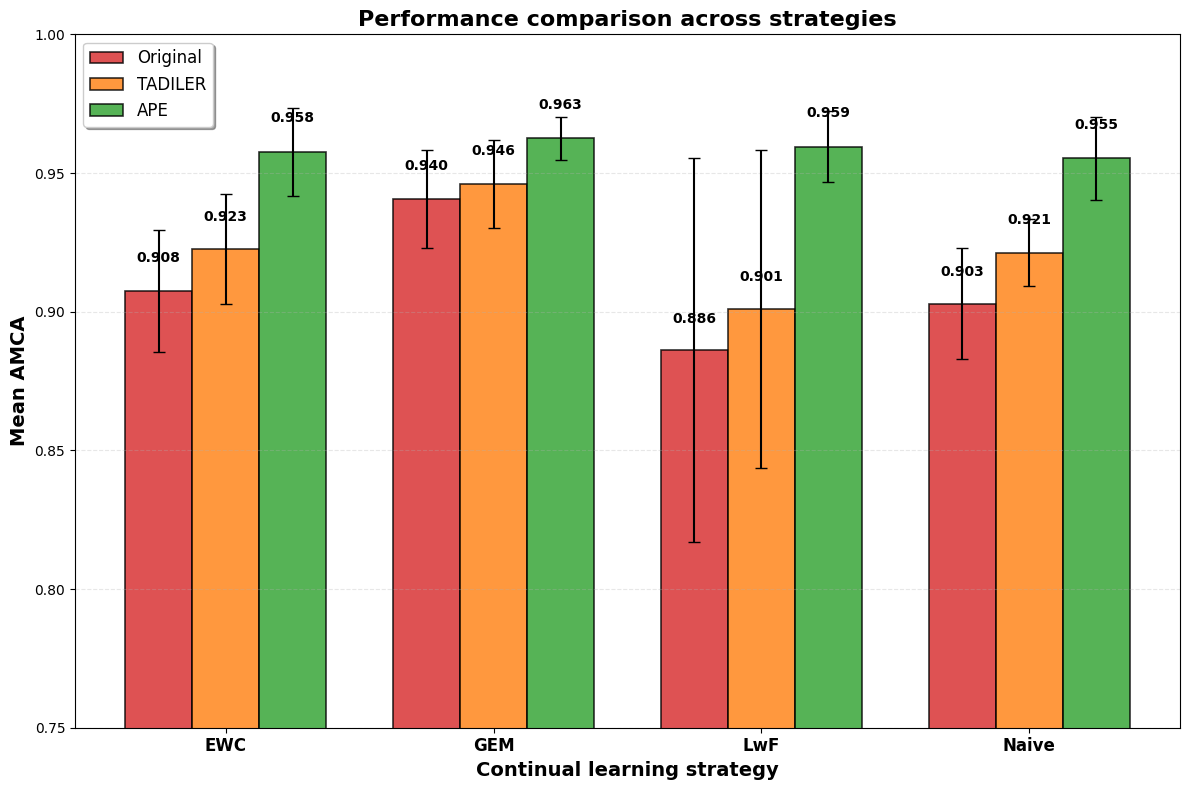


2. AMCA vs forgetting trade-off:
AMCA vs forgetting plot saved to amca_forgetting.pdf


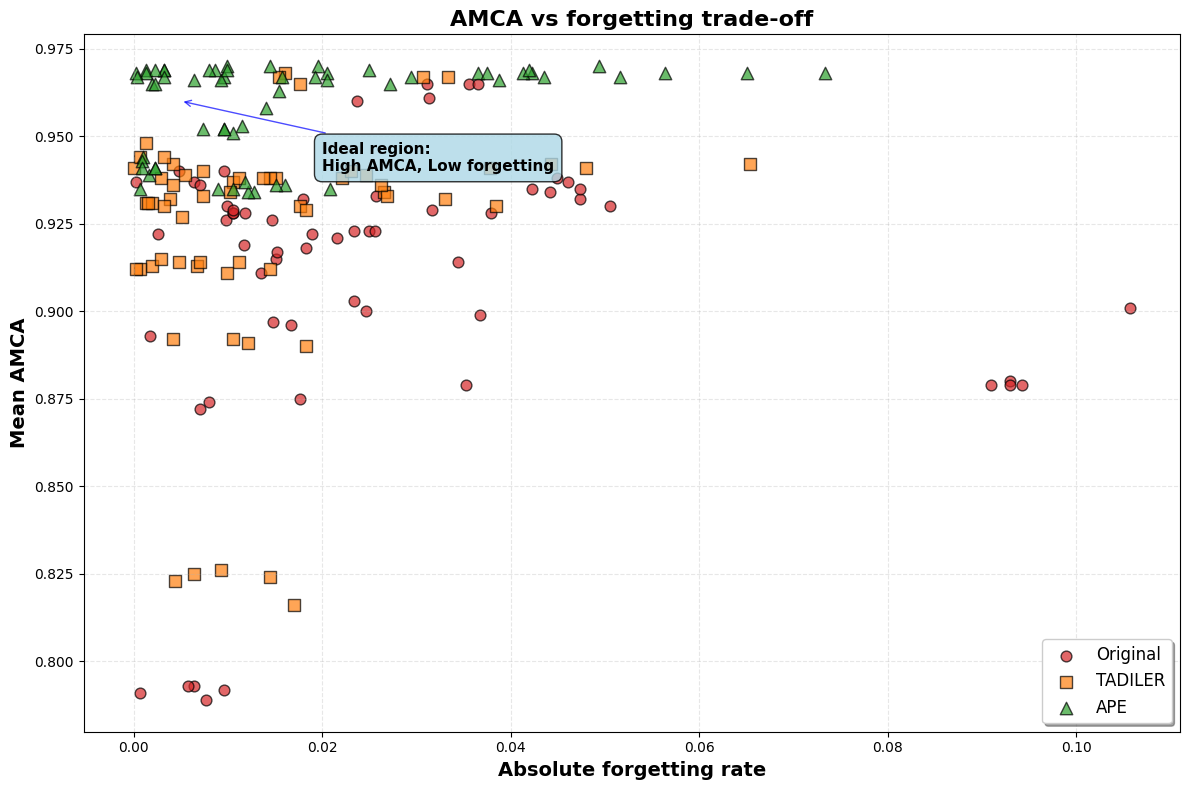


3. Performance evolution across KNN values:
Performance evolution plot saved to performance_evolution.pdf


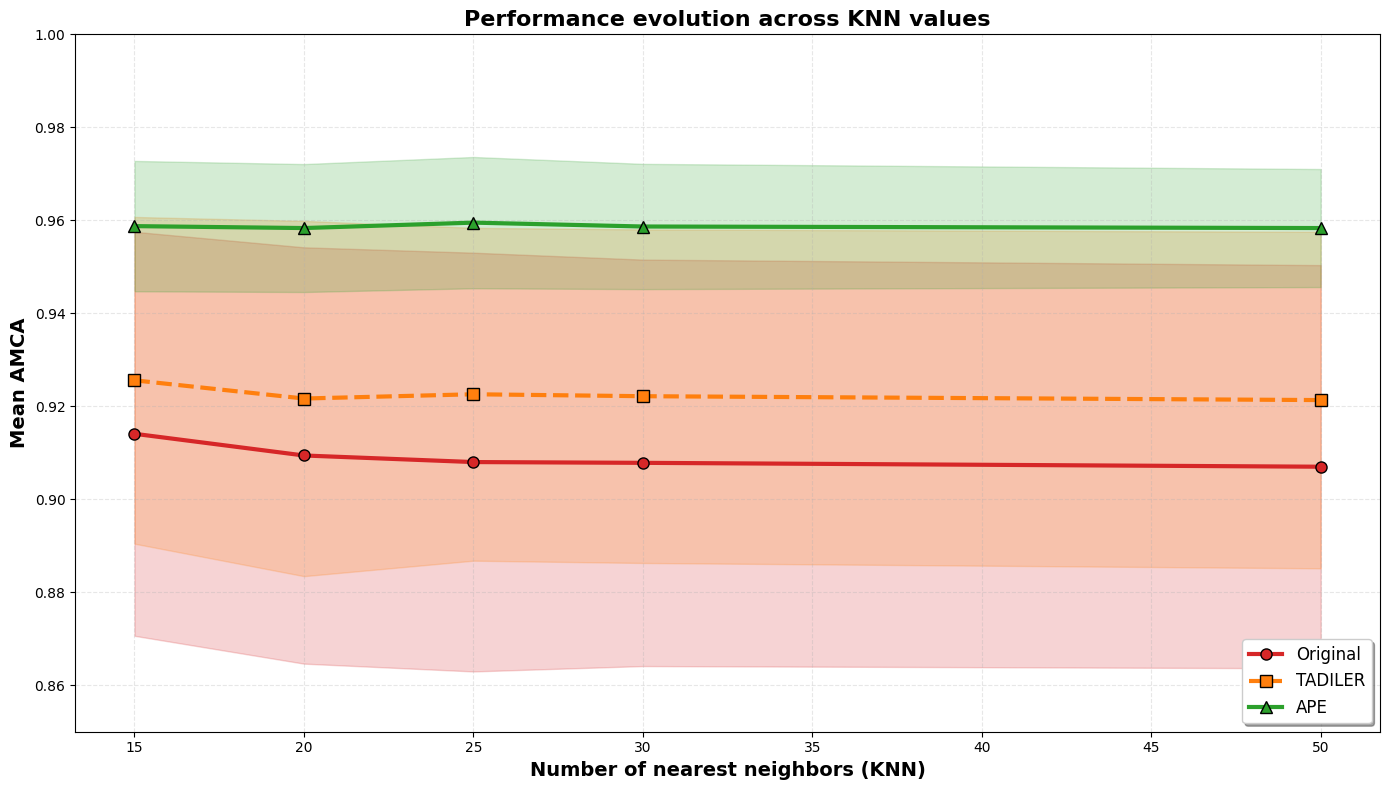

Radar plot saved to radar_overall.pdf


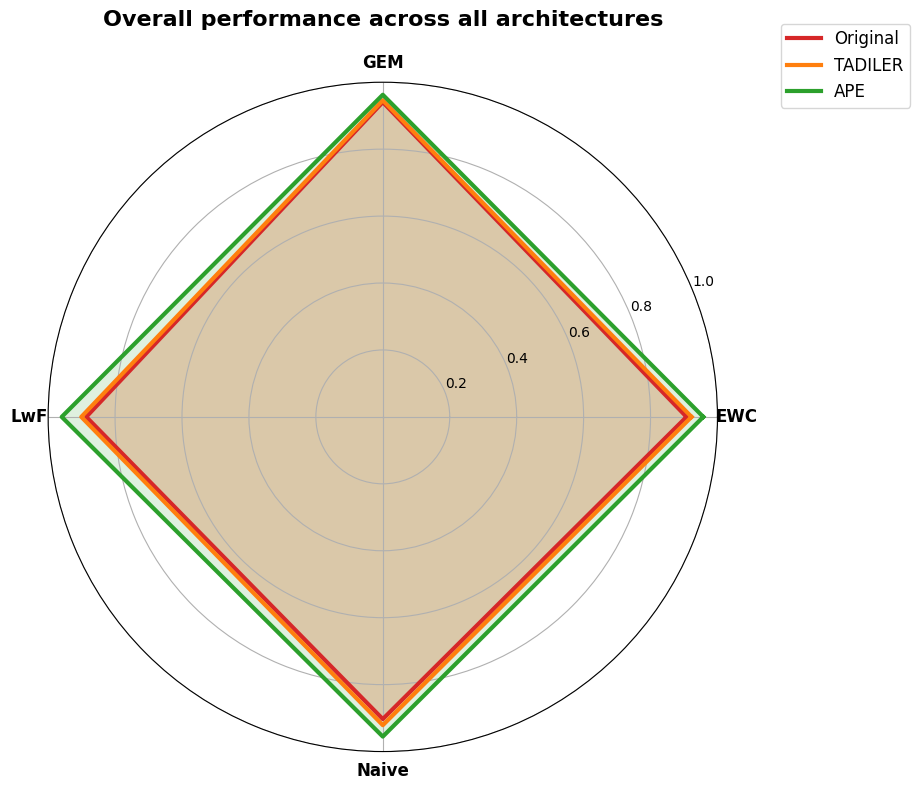

In [7]:
create_journal_plots()

## Latex  table

In [8]:
from ape.latex_tables import generate_latex_table, generate_separate_tables, print_latex_table


In [69]:
df = pd.read_csv('comparison.csv')

# Print both tables to console
print_latex_table(df)

# Save both tables to one file
generate_latex_table(df, save_path='comparison_tables.tex')

# Save tables to separate files  
generate_separate_tables(df, 
                        save_path_1='table_naive_gem.tex',
                        save_path_2='table_lwf_ewc.tex')

\begin{table*}
\scriptsize
  {\caption{Comparison of Mean AMCA scores and forgetting (parentheses) for Naive and GEM strategies across different base models. Boldface
indicates superior performance among \textit{Original}, \textit{TADILER}, and \textit{APE} methods based on Mean AMCA. Averages are
computed across different NN values for each base model.}
  \label{tab:amca_comparison_naive_gem}
}
  {\begin{tabular}{llcccccc}
  
  \toprule
  \bfseries Model & \bfseries NN & \multicolumn{3}{c}{\bfseries Naive} & \multicolumn{3}{c}{\bfseries GEM} \\
  \cmidrule(lr){3-5} \cmidrule(lr){6-8}
 &  \bfseries  & \bfseries Original & \bfseries TADILER & \bfseries APE & \bfseries Original & \bfseries TADILER & \bfseries APE \\
  \midrule
\multirow{7}{*}{\textbf{Attention}} & 15 & 0.929(3.4) & 0.936(3.7) & \textbf{0.967(3.5)} & 0.965(3.4) & 0.967(3.5) & \textbf{0.968(1.3)} \\
 & 20 & 0.926(4.3) & 0.938(4.2) & \textbf{0.963(4.2)} & 0.965(3.2) & \textbf{0.968(4.2)} & 0.967(2.4) \\
 & 25 & 0.922(4.9) &

('\\begin{table*}\n\\scriptsize\n  {\\caption{Comparison of Mean AMCA scores and forgetting (parentheses) for Naive and GEM strategies across different base models. Boldface\nindicates superior performance among \\textit{Original}, \\textit{TADILER}, and \\textit{APE} methods based on Mean AMCA. Averages are\ncomputed across different NN values for each base model.}\n  \\label{tab:amca_comparison_naive_gem}\n}\n  {\\begin{tabular}{llcccccc}\n  \n  \\toprule\n  \\bfseries Model & \\bfseries NN & \\multicolumn{3}{c}{\\bfseries Naive} & \\multicolumn{3}{c}{\\bfseries GEM} \\\\\n  \\cmidrule(lr){3-5} \\cmidrule(lr){6-8}\n &  \\bfseries  & \\bfseries Original & \\bfseries TADILER & \\bfseries APE & \\bfseries Original & \\bfseries TADILER & \\bfseries APE \\\\\n  \\midrule\n\\multirow{7}{*}{\\textbf{Attention}} & 15 & 0.929(3.4) & 0.936(3.7) & \\textbf{0.967(3.5)} & 0.965(3.4) & 0.967(3.5) & \\textbf{0.968(1.3)} \\\\\n & 20 & 0.926(4.3) & 0.938(4.2) & \\textbf{0.963(4.2)} & 0.965(3.2) & \\t